# Water Index Comparison: Original vs Bilinear vs Bicubic

This notebook is plug-and-play for your converted outputs.

It does the following:
1. Randomly samples 5 high-resolution scenes from `data/sat_images`.
2. Matches each sampled scene to the original source TIFF.
3. Computes **NDWI** and **MNDWI** for `original`, `bilinear`, and `bicubic`.
4. Plots index maps for quick visual comparison.
5. Plots thresholded water masks using both **Otsu** and **weighted peaks** for the same examples.

Expected high-res layout:
- `data/sat_images/<site>/<bilinear|bicubic>/<relative_path_to_tiff>`

Expected original layout:
- `<original_root>/<site>/<relative_path_to_tiff>`

In [20]:
import os
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import rasterio

In [21]:
# ---- Configuration ----
PROJECT_ROOT = Path.cwd()

# Where converted bilinear/bicubic images were saved.
highres_root = PROJECT_ROOT / 'data' / 'sat_images'

# Original source imagery root.
original_root = Path(os.path.join(
    os.path.dirname(os.getcwd()),
    'SDS_performance_analysis',
    'data',
    'sat_images',
))

sample_count = 5
examples_to_plot = 3  # same subset used in detailed threshold plots
rng_seed = 42

print('highres_root :', highres_root.resolve())
print('original_root:', original_root.resolve())

highres_root : C:\Users\jnicolow\Documents\research\CRC\change_tiff_resolution\data\sat_images
original_root: C:\Users\jnicolow\Documents\research\CRC\SDS_performance_analysis\data\sat_images


In [23]:
@dataclass
class ScenePaths:
    site: str
    rel: Path
    original: Path
    bilinear: Path
    bicubic: Path


def _normalize_name(name: str) -> str:
    return ''.join(ch for ch in name.lower() if ch.isalnum())


def _band_aliases() -> Dict[str, Tuple[str, ...]]:
    return {
        'blue': ('blue', 'b', 'band2', 'b2'),
        'green': ('green', 'g', 'band3', 'b3'),
        'red': ('red', 'r', 'band4', 'b4'),
        'nir': ('nir', 'nearinfrared', 'nearir', 'band5', 'b5', 'nir08', 'nir1'),
        'swir1': ('swir1', 'swir', 'shortwaveinfrared1', 'swir16', 'band6', 'b6'),
    }


def _extract_band_names(src: rasterio.io.DatasetReader) -> List[str]:
    names: List[str] = []
    for i in range(1, src.count + 1):
        desc = src.descriptions[i - 1] if src.descriptions else None
        tags = src.tags(i)
        tag_name = tags.get('name') or tags.get('band_name') or tags.get('long_name')
        chosen = (desc or tag_name or f'band{i}').strip()
        names.append(chosen)
    return names


def _find_band_index(band_names: List[str], key: str) -> int:
    key = key.lower()
    aliases = tuple(_normalize_name(a) for a in _band_aliases()[key])
    normalized = [_normalize_name(n) for n in band_names]

    for idx, n in enumerate(normalized):
        if n in aliases:
            return idx

    for idx, n in enumerate(normalized):
        if any(a in n for a in aliases):
            return idx

    raise ValueError(f"Could not find band '{key}' in names: {band_names}")


def _safe_index(a: np.ndarray, b: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    denom = a + b
    out = (a - b) / (denom + eps)
    return np.clip(out, -1.0, 1.0)


def _to_display_rgb(data: np.ndarray, band_names: List[str]) -> np.ndarray:
    # data shape: (bands, H, W)
    try:
        r = data[_find_band_index(band_names, 'red')]
        g = data[_find_band_index(band_names, 'green')]
        b = data[_find_band_index(band_names, 'blue')]
        rgb = np.stack([r, g, b], axis=-1).astype(np.float32)
    except Exception:
        c = min(3, data.shape[0])
        rgb = np.transpose(data[:c], (1, 2, 0)).astype(np.float32)

    rgb_min = np.nanpercentile(rgb, 2)
    rgb_max = np.nanpercentile(rgb, 98)
    if rgb_max <= rgb_min:
        rgb_max = rgb_min + 1.0
    rgb = (rgb - rgb_min) / (rgb_max - rgb_min)
    return np.clip(rgb, 0, 1)


def load_indices(path: Path) -> Dict[str, np.ndarray]:
    with rasterio.open(path) as src:
        data = src.read().astype(np.float32)
        band_names = _extract_band_names(src)
        print(f'{band_names=}')

    g = data[_find_band_index(band_names, 'green')]
    nir = data[_find_band_index(band_names, 'nir')]
    swir1 = data[_find_band_index(band_names, 'swir1')]

    ndwi = _safe_index(g, nir)
    mndwi = _safe_index(g, swir1)

    return {
        'band_names': np.array(band_names, dtype=object),
        'rgb': _to_display_rgb(data, band_names),
        'ndwi': ndwi,
        'mndwi': mndwi,
    }

In [24]:
def discover_triplets(highres_root: Path, original_root: Path) -> List[ScenePaths]:
    bilinear_files = sorted(
        list(highres_root.glob('**/bilinear/**/*.tif'))
        + list(highres_root.glob('**/bilinear/**/*.tiff'))
    )
    triplets: List[ScenePaths] = []

    for bilinear in bilinear_files:
        # Expected: highres_root / <site> / bilinear / <rel>
        try:
            rel_to_root = bilinear.relative_to(highres_root)
        except ValueError:
            continue

        parts = rel_to_root.parts
        if len(parts) < 3:
            continue

        site = parts[0]
        if parts[1].lower() != 'bilinear':
            continue

        rel = Path(*parts[2:])
        bicubic = highres_root / site / 'bicubic' / rel
        original = original_root / site / rel

        if bicubic.exists() and original.exists():
            triplets.append(
                ScenePaths(
                    site=site,
                    rel=rel,
                    original=original,
                    bilinear=bilinear,
                    bicubic=bicubic,
                )
            )

    return triplets


all_triplets = discover_triplets(highres_root, original_root)
print(f'Found {len(all_triplets)} matched original/bilinear/bicubic triplets.')
if len(all_triplets) == 0:
    raise RuntimeError('No matched triplets found. Check highres_root/original_root and folder layout.')

rng = np.random.default_rng(rng_seed)
k = min(sample_count, len(all_triplets))
chosen_idx = rng.choice(len(all_triplets), size=k, replace=False)
samples = [all_triplets[i] for i in chosen_idx]

print(f'Randomly selected {len(samples)} scenes:')
for s in samples:
    print('-', s.site, '|', s.rel)

Found 4903 matched original/bilinear/bicubic triplets.
Randomly selected 5 scenes:
- northcarolinaduck | S2\S2_20160809_154912.tif
- hawaiiwaikiki | S2\S2_20190421T210929_20190421T210930_T04QFJ.SWIR1.tif
- northcarolinaduck | L5\L5_LT05_014035_19890327.SWIR2.tif
- australianarrabeen | S2\S2_20151218_235302.tif
- hawaiiwaikiki | S2\S2_20190322_210929.tif


In [25]:
# Compute NDWI/MNDWI for each selected scene across original/bilinear/bicubic.
# If a scene has unsupported/generic band naming (e.g., band1), skip it and continue.
scene_results = []
skipped_scenes = []

for s in samples:
    try:
        scene_results.append(
            {
                'scene': s,
                'original': load_indices(s.original),
                'bilinear': load_indices(s.bilinear),
                'bicubic': load_indices(s.bicubic),
            }
        )
    except (KeyError, ValueError) as e:
        skipped_scenes.append((s, str(e)))
        print(f"Skipping scene due to band/index issue: {s.site} | {s.rel} | {e}")

print(f'Computed indices for {len(scene_results)} valid scene(s).')
print(f'Skipped {len(skipped_scenes)} scene(s).')

band_names=['Red', 'Green', 'Blue', 'NIR', 'UDM', 'SWIR1', 'SWIR2']
band_names=['Red', 'Green', 'Blue', 'NIR', 'UDM', 'SWIR1', 'SWIR2']
band_names=['Red', 'Green', 'Blue', 'NIR', 'UDM', 'SWIR1', 'SWIR2']
band_names=['band1']
Skipping scene due to band/index issue: hawaiiwaikiki | S2\S2_20190421T210929_20190421T210930_T04QFJ.SWIR1.tif | Could not find band 'green' in names: ['band1']
band_names=['band1']
Skipping scene due to band/index issue: northcarolinaduck | L5\L5_LT05_014035_19890327.SWIR2.tif | Could not find band 'green' in names: ['band1']
band_names=['Red', 'Green', 'Blue', 'NIR', 'UDM', 'SWIR1', 'SWIR2']
band_names=['Red', 'Green', 'Blue', 'NIR', 'UDM', 'SWIR1', 'SWIR2']
band_names=['Red', 'Green', 'Blue', 'NIR', 'UDM', 'SWIR1', 'SWIR2']
band_names=['Red', 'Green', 'Blue', 'NIR', 'UDM', 'SWIR1', 'SWIR2']
band_names=['Red', 'Green', 'Blue', 'NIR', 'UDM', 'SWIR1', 'SWIR2']
band_names=['Red', 'Green', 'Blue', 'NIR', 'UDM', 'SWIR1', 'SWIR2']
Computed indices for 3 valid scene(s).

C:\Users\jnicolow\AppData\Local\Temp\ipykernel_15936\2927224757.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


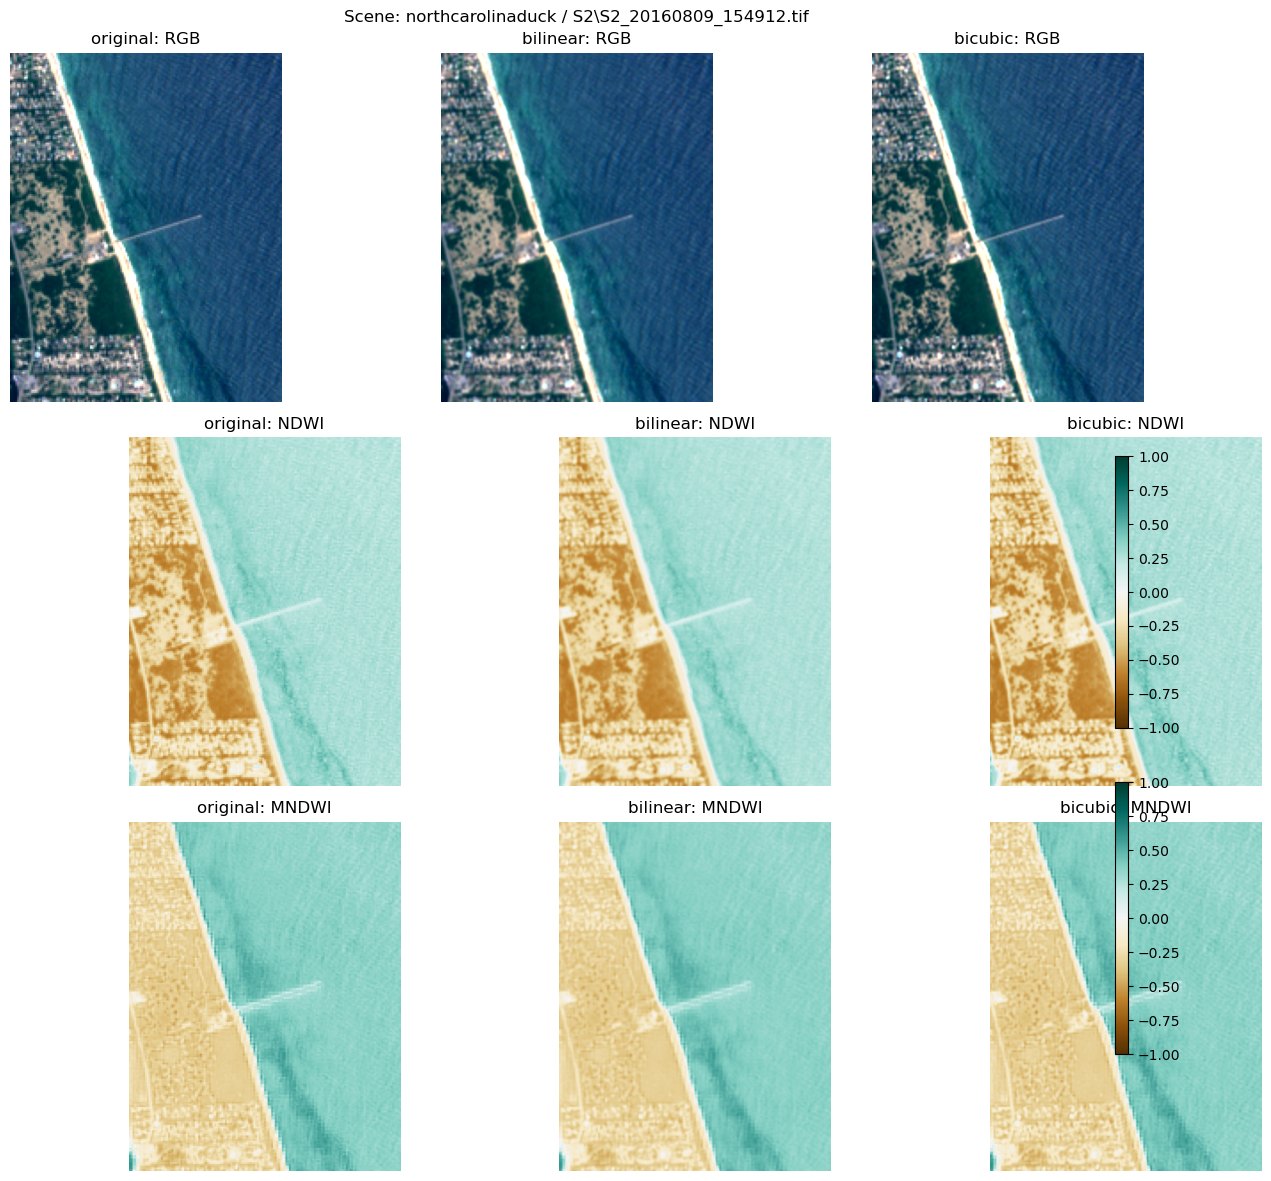

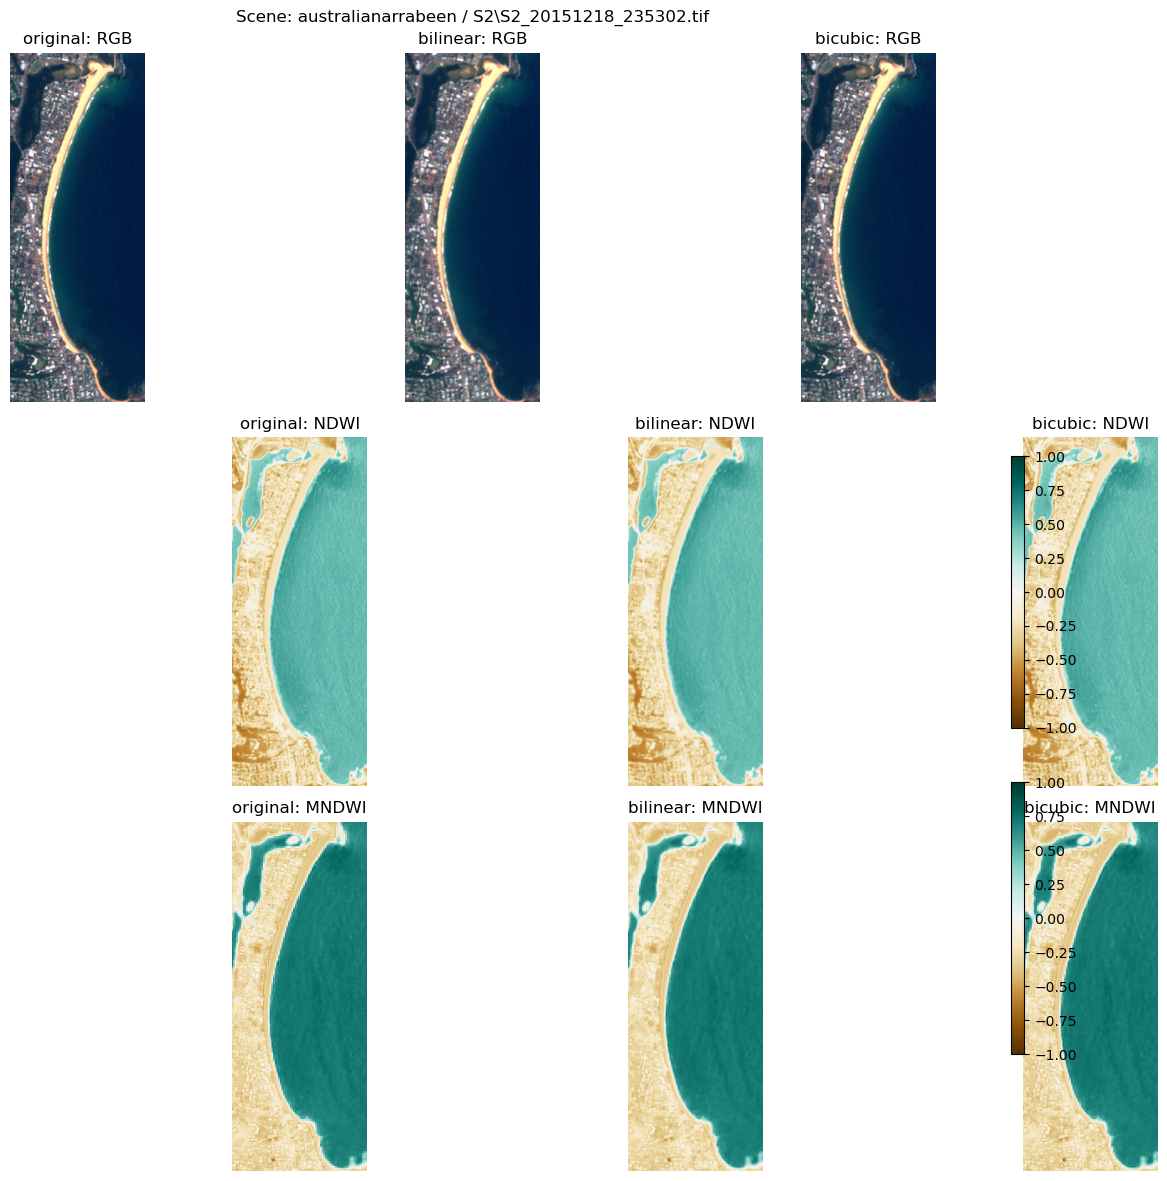

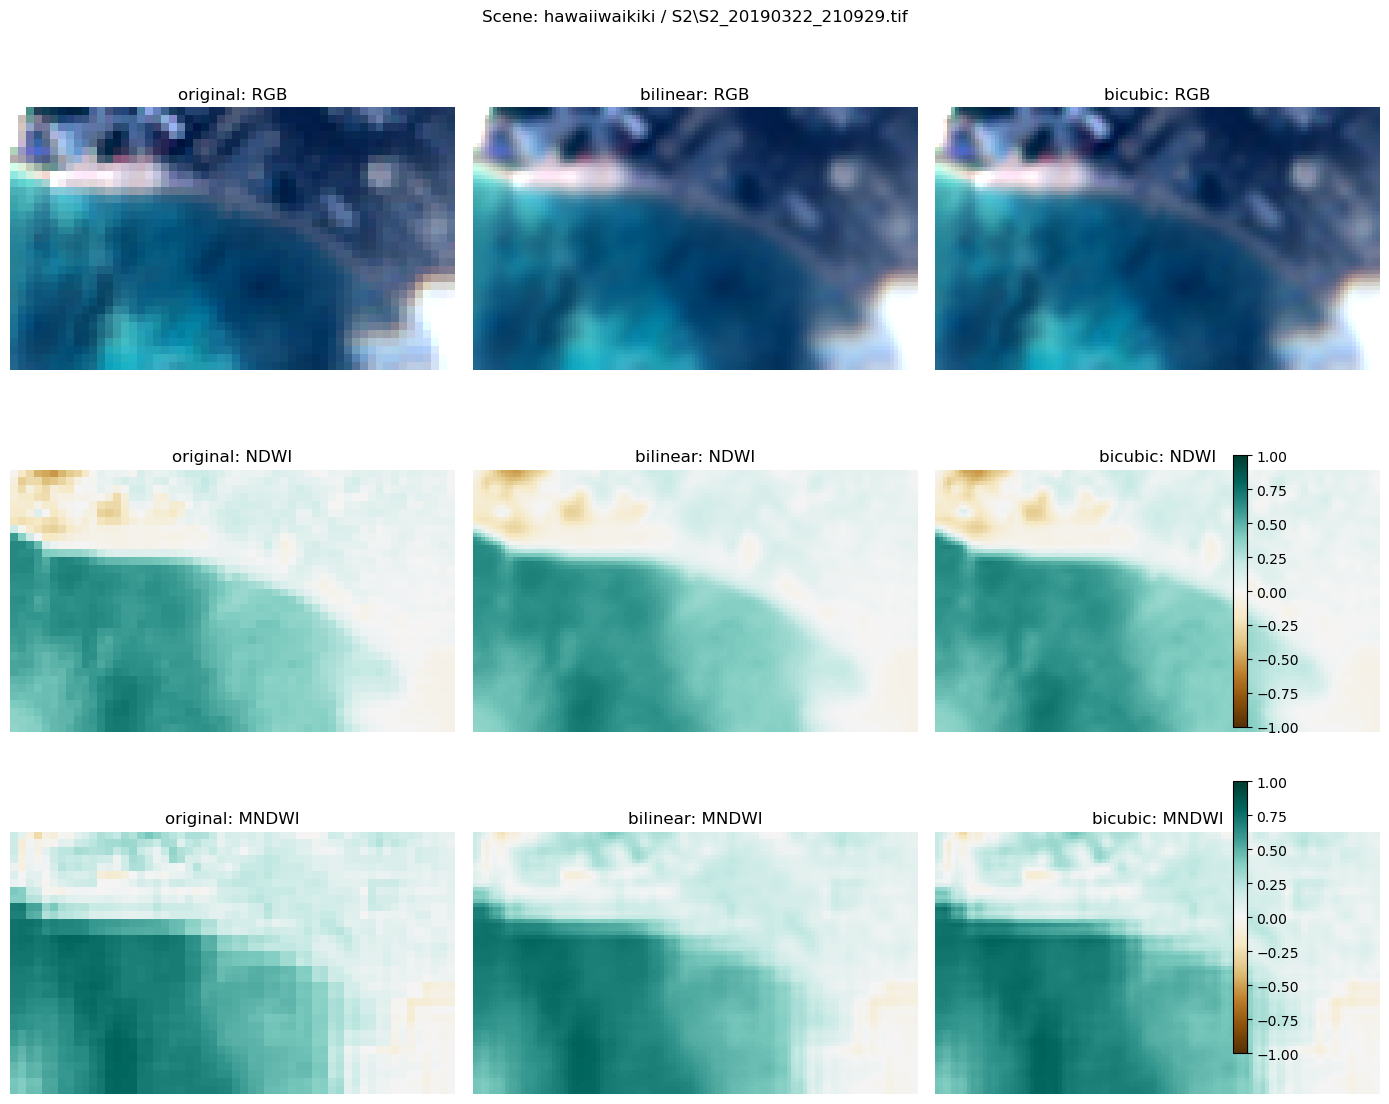

In [26]:
# Quick visual check: RGB + NDWI + MNDWI for a few examples.
show_n = min(examples_to_plot, len(scene_results))
methods = ['original', 'bilinear', 'bicubic']

for i in range(show_n):
    item = scene_results[i]
    scene = item['scene']

    fig, axes = plt.subplots(3, 3, figsize=(14, 12))
    fig.suptitle(f"Scene: {scene.site} / {scene.rel}", fontsize=12)

    for c, method in enumerate(methods):
        payload = item[method]

        axes[0, c].imshow(payload['rgb'])
        axes[0, c].set_title(f"{method}: RGB")
        axes[0, c].axis('off')

        im1 = axes[1, c].imshow(payload['ndwi'], cmap='BrBG', vmin=-1, vmax=1)
        axes[1, c].set_title(f"{method}: NDWI")
        axes[1, c].axis('off')

        im2 = axes[2, c].imshow(payload['mndwi'], cmap='BrBG', vmin=-1, vmax=1)
        axes[2, c].set_title(f"{method}: MNDWI")
        axes[2, c].axis('off')

    fig.colorbar(im1, ax=axes[1, :], fraction=0.02, pad=0.02)
    fig.colorbar(im2, ax=axes[2, :], fraction=0.02, pad=0.02)
    plt.tight_layout()
    plt.show()

In [27]:
# ---- Thresholding helpers: Otsu + Weighted Peaks ----
def otsu_threshold(img: np.ndarray, bins: int = 256) -> float:
    vals = img[np.isfinite(img)].ravel()
    if vals.size == 0:
        return 0.0

    vmin, vmax = float(vals.min()), float(vals.max())
    if vmax <= vmin:
        return vmin

    hist, edges = np.histogram(vals, bins=bins, range=(vmin, vmax))
    hist = hist.astype(np.float64)
    centers = (edges[:-1] + edges[1:]) / 2.0

    w0 = np.cumsum(hist)
    w1 = np.cumsum(hist[::-1])[::-1]

    mu = np.cumsum(hist * centers)
    mu_t = mu[-1]

    eps = 1e-12
    mu0 = mu / (w0 + eps)
    mu1 = (mu_t - mu) / (w1 + eps)

    sigma_b2 = w0 * w1 * (mu0 - mu1) ** 2
    idx = int(np.nanargmax(sigma_b2))
    return float(centers[idx])


def weighted_peaks_threshold(img: np.ndarray, bins: int = 256, min_sep_bins: int = 12) -> float:
    vals = img[np.isfinite(img)].ravel()
    if vals.size == 0:
        return 0.0

    vmin, vmax = float(vals.min()), float(vals.max())
    if vmax <= vmin:
        return vmin

    hist, edges = np.histogram(vals, bins=bins, range=(vmin, vmax))
    centers = (edges[:-1] + edges[1:]) / 2.0

    if hist.sum() == 0:
        return float(np.nanmean(vals))

    first = int(np.argmax(hist))

    # pick second peak with a minimum separation from the first
    mask = np.ones_like(hist, dtype=bool)
    lo = max(0, first - min_sep_bins)
    hi = min(len(hist), first + min_sep_bins + 1)
    mask[lo:hi] = False

    if np.any(mask):
        second_candidates = np.where(mask)[0]
        second = int(second_candidates[np.argmax(hist[second_candidates])])
    else:
        return float(centers[first])

    p1, p2 = sorted([first, second])
    h1, h2 = hist[p1], hist[p2]
    c1, c2 = centers[p1], centers[p2]

    if (h1 + h2) <= 0:
        return float((c1 + c2) / 2.0)

    return float((h1 * c1 + h2 * c2) / (h1 + h2))

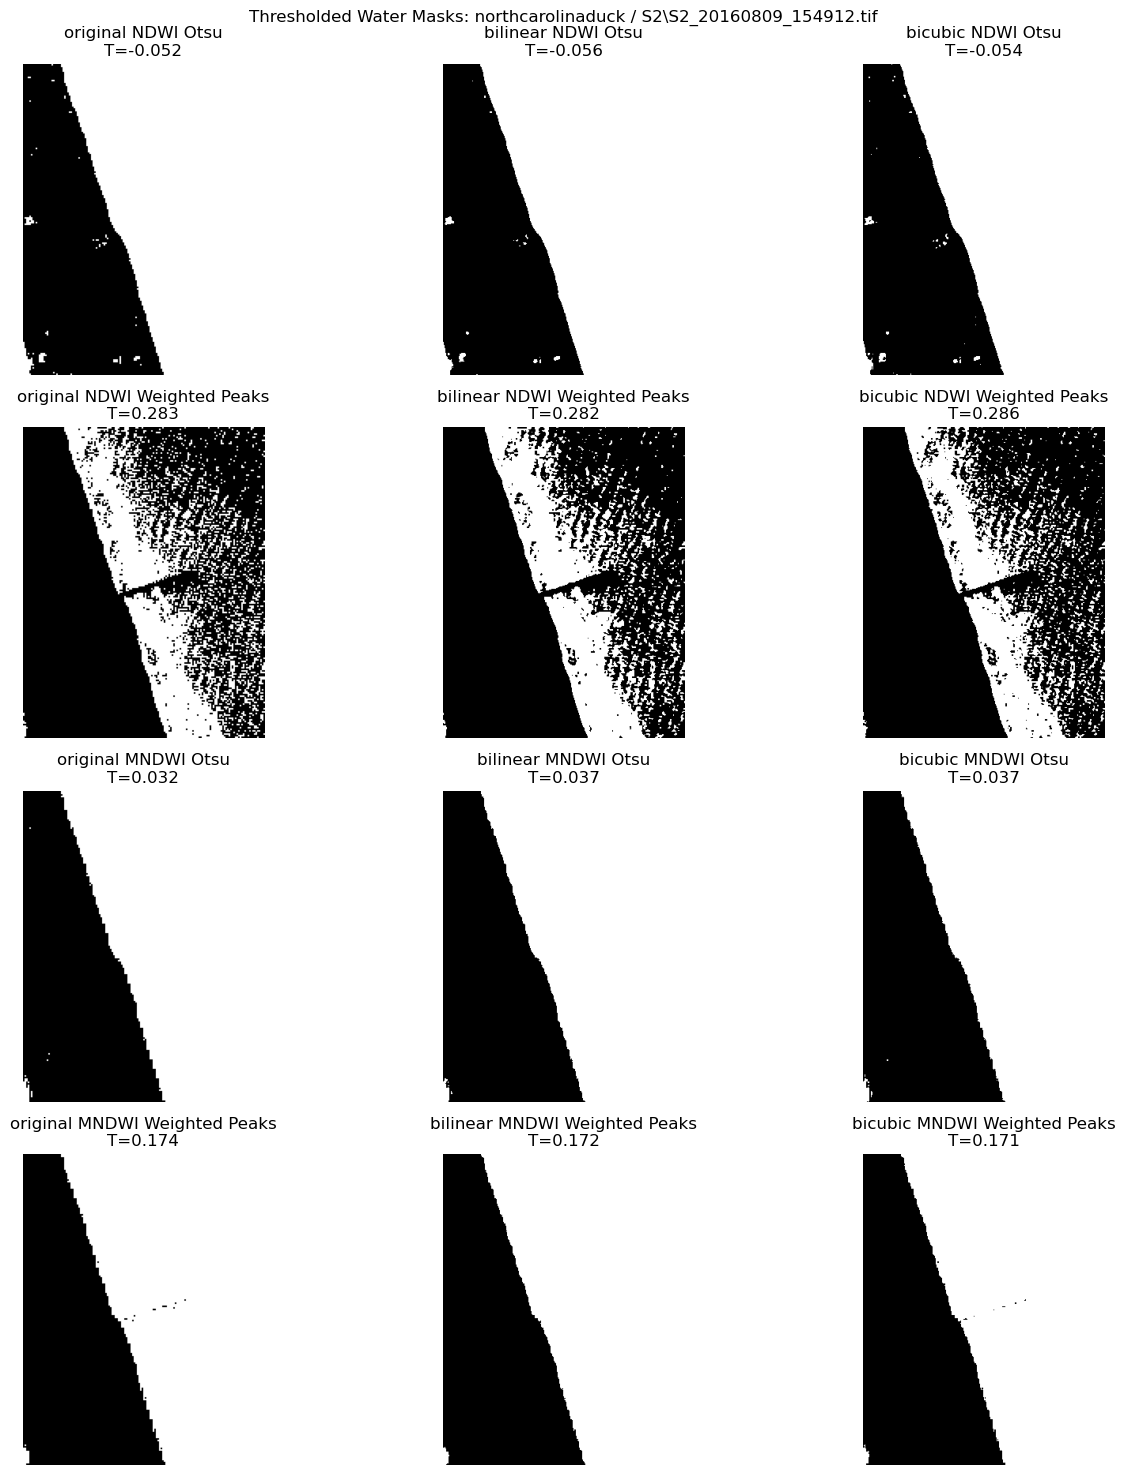

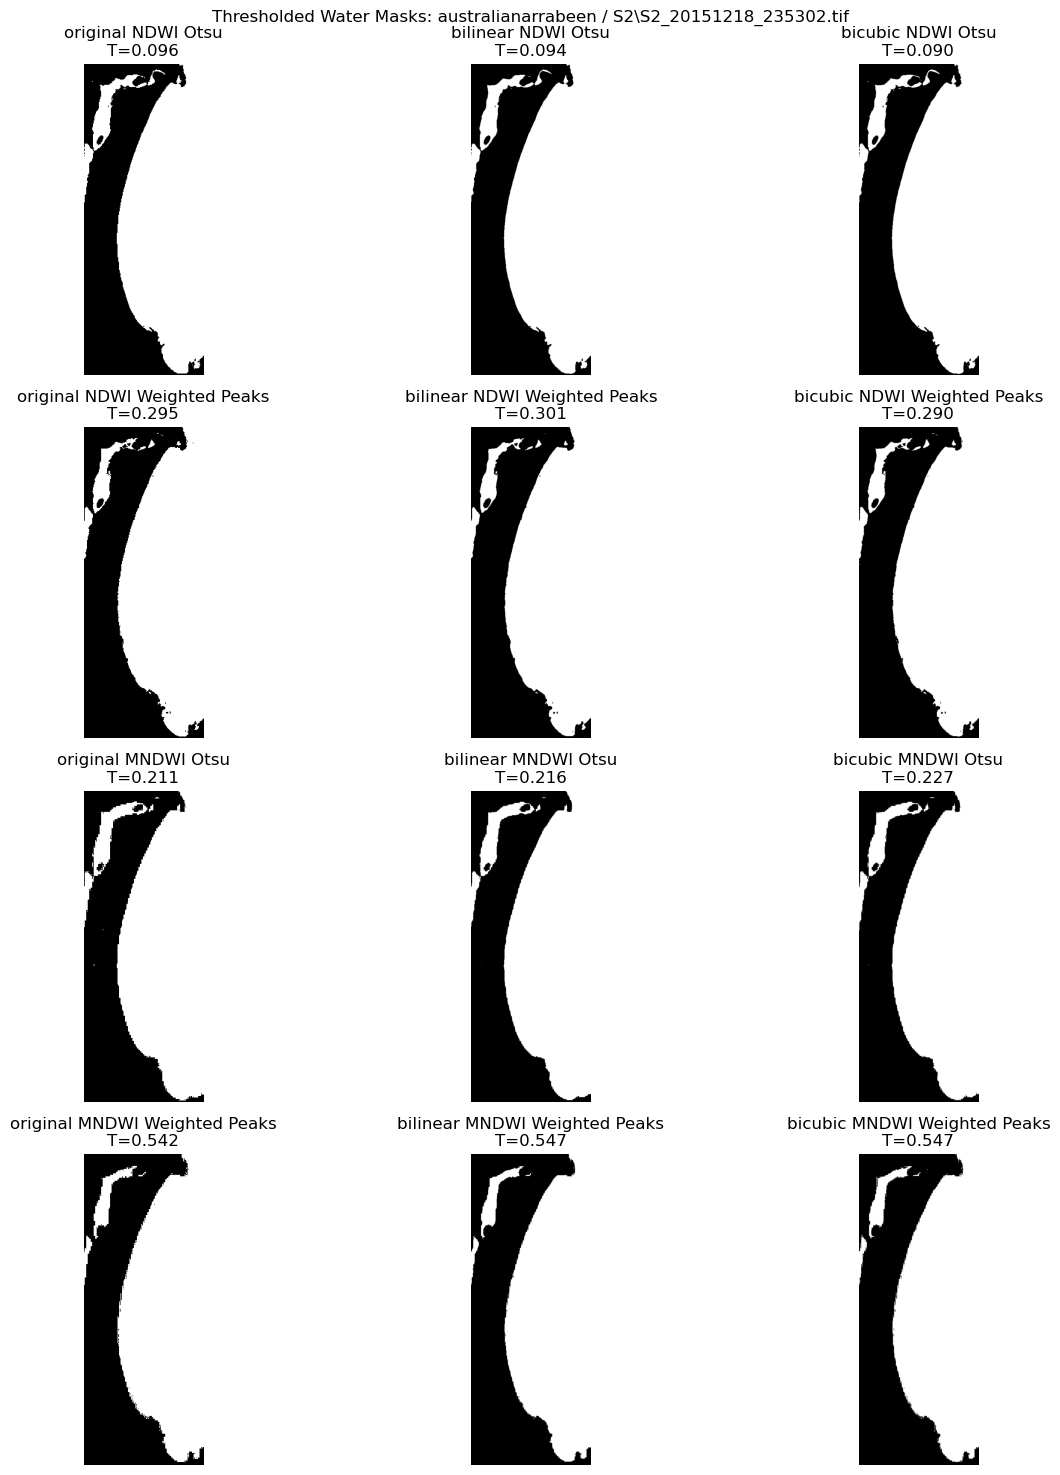

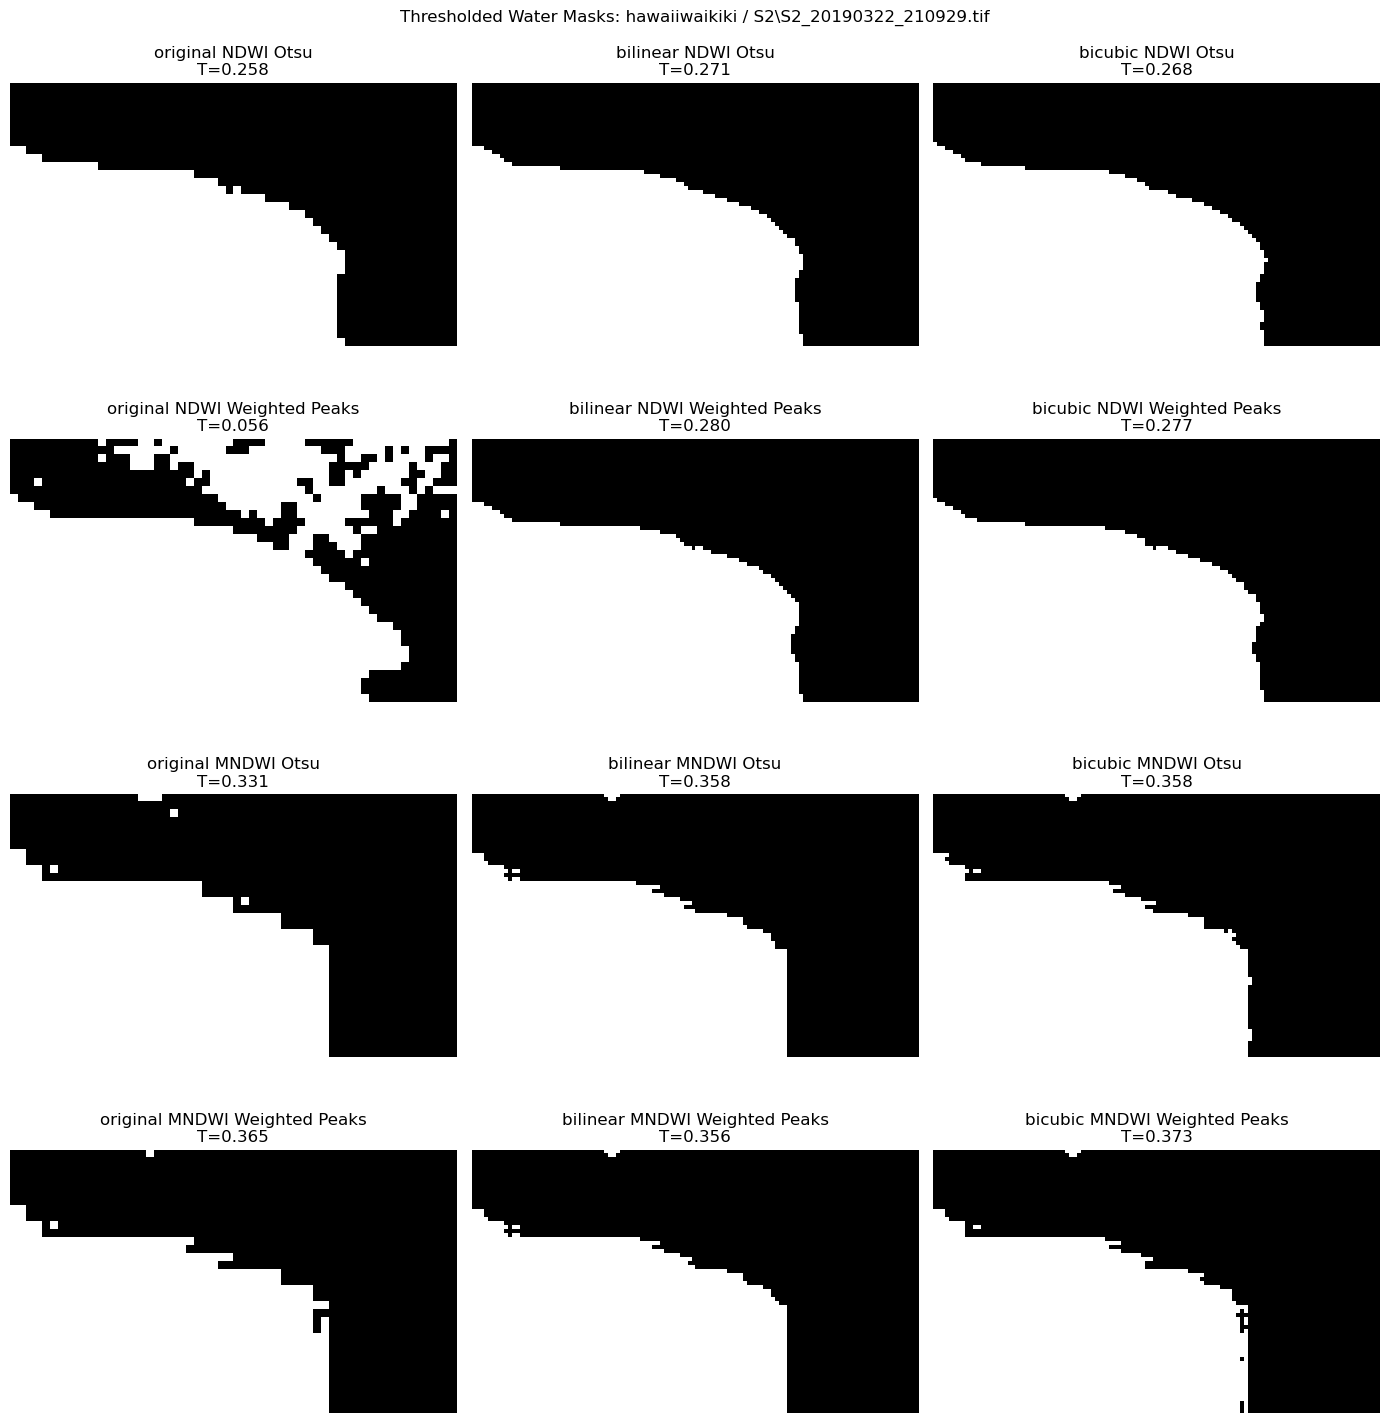

In [28]:
# Detailed threshold comparison for the same examples (Otsu and weighted-peaks).
show_n = min(examples_to_plot, len(scene_results))
methods = ['original', 'bilinear', 'bicubic']

for i in range(show_n):
    item = scene_results[i]
    scene = item['scene']

    fig, axes = plt.subplots(4, 3, figsize=(14, 15))
    fig.suptitle(f"Thresholded Water Masks: {scene.site} / {scene.rel}", fontsize=12)

    for c, method in enumerate(methods):
        ndwi = item[method]['ndwi']
        mndwi = item[method]['mndwi']

        t_ndwi_o = otsu_threshold(ndwi)
        t_ndwi_w = weighted_peaks_threshold(ndwi)
        t_mndwi_o = otsu_threshold(mndwi)
        t_mndwi_w = weighted_peaks_threshold(mndwi)

        axes[0, c].imshow(ndwi > t_ndwi_o, cmap='gray')
        axes[0, c].set_title(f"{method} NDWI Otsu\nT={t_ndwi_o:.3f}")
        axes[0, c].axis('off')

        axes[1, c].imshow(ndwi > t_ndwi_w, cmap='gray')
        axes[1, c].set_title(f"{method} NDWI Weighted Peaks\nT={t_ndwi_w:.3f}")
        axes[1, c].axis('off')

        axes[2, c].imshow(mndwi > t_mndwi_o, cmap='gray')
        axes[2, c].set_title(f"{method} MNDWI Otsu\nT={t_mndwi_o:.3f}")
        axes[2, c].axis('off')

        axes[3, c].imshow(mndwi > t_mndwi_w, cmap='gray')
        axes[3, c].set_title(f"{method} MNDWI Weighted Peaks\nT={t_mndwi_w:.3f}")
        axes[3, c].axis('off')

    plt.tight_layout()
    plt.show()

## Notes
- If any file uses different band naming, update aliases in `_band_aliases()`.
- Thresholding uses `index > threshold` for both NDWI and MNDWI masks.
- Increase `sample_count` or `examples_to_plot` as needed.